# Assignment 

Name: yash vyas<br>
Roll No.: IT-2K24-97

## Question 7: Ordinary Differential Equations

In [6]:
def ode_func(x, y):
    return x + y

### Method 7.1: Euler Method

**Assumptions**

- f(x, y) is continuous in the interval.
- Initial condition y(x0) = y0 is given.
- Step size h > 0 and number of steps N are given.

**Algorithm (Euler Method)**

1. Start
2. Read f(x, y), x0, y0, h, N
3. Set x = x0, y = y0
4. Repeat for i = 1 to N
5.    y = y + h * f(x, y)
6.    x = x + h
7. End Repeat
8. Print y
9. Stop
10. End

Approximate y(1): 3.1874849202


,step,x,y
0,0,0.0,1.000000
1,1,0.1,1.100000
2,2,0.2,1.220000
3,3,0.3,1.362000
4,4,0.4,1.528200
5,5,0.5,1.721020
6,6,0.6,1.943122
7,7,0.7,2.197434
8,8,0.8,2.487178
9,9,0.9,2.815895


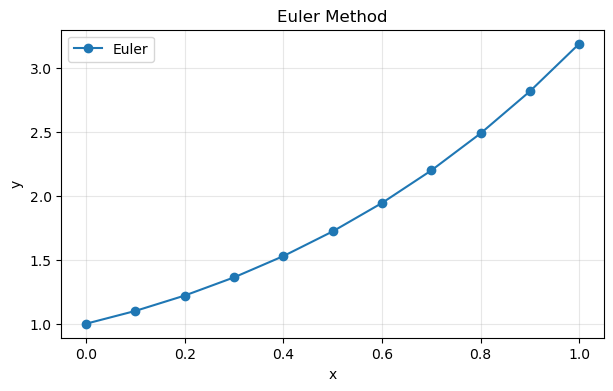

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def euler_method(ode, x0, y0, h, steps):
    x = x0
    y = y0
    points = [(x, y)]
    rows = [{"step": 0, "x": x, "y": y}]

    for i in range(1, steps + 1):
        y = y + h * ode(x, y)
        x = x + h
        points.append((x, y))
        rows.append({"step": i, "x": x, "y": y})

    return points, pd.DataFrame(rows)


points, table = euler_method(ode_func, 0.0, 1.0, 0.1, 10)
print("Approximate y(1):", points[-1][1])
display(table)

xs = [p[0] for p in points]
ys = [p[1] for p in points]
plt.figure(figsize=(7, 4))
plt.plot(xs, ys, marker="o", label="Euler")
plt.title("Euler Method")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Time Complexity: O(n)

Space Complexity: O(n)

### Method 7.2: Single Step Method (Runge-Kutta Method)

**Assumptions**

- f(x, y) is continuous in the interval.
- Initial condition y(x0) = y0 is given.
- Step size h > 0 and number of steps N are given.

**Algorithm (Runge-Kutta 4th Order)**

1. Start
2. Read f(x, y), x0, y0, h, N
3. Set x = x0, y = y0
4. Repeat for i = 1 to N
5.    k1 = f(x, y)
6.    k2 = f(x + h/2, y + h*k1/2)
7.    k3 = f(x + h/2, y + h*k2/2)
8.    k4 = f(x + h, y + h*k3)
9.    y = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
10.   x = x + h
11. End Repeat
12. Print y
13. Stop
14. End

Approximate y(1): 3.4365594882703316


,step,x,y
0,0,0.0,1.000000
1,1,0.1,1.110342
2,2,0.2,1.242805
3,3,0.3,1.399717
4,4,0.4,1.583648
5,5,0.5,1.797441
6,6,0.6,2.044236
7,7,0.7,2.327503
8,8,0.8,2.651079
9,9,0.9,3.019203


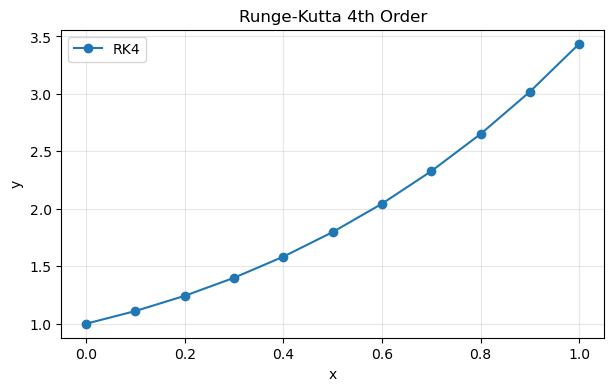

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def runge_kutta_4(ode, x0, y0, h, steps):
    x = x0
    y = y0
    points = [(x, y)]
    rows = [{"step": 0, "x": x, "y": y}]

    for i in range(1, steps + 1):
        k1 = ode(x, y)
        k2 = ode(x + h / 2, y + h * k1 / 2)
        k3 = ode(x + h / 2, y + h * k2 / 2)
        k4 = ode(x + h, y + h * k3)

        y = y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        x = x + h
        points.append((x, y))
        rows.append({"step": i, "x": x, "y": y})

    return points, pd.DataFrame(rows)


points, table = runge_kutta_4(ode_func, 0.0, 1.0, 0.1, 10)
print("Approximate y(1):", points[-1][1])
display(table)

xs = [p[0] for p in points]
ys = [p[1] for p in points]
plt.figure(figsize=(7, 4))
plt.plot(xs, ys, marker="o", label="RK4")
plt.title("Runge-Kutta 4th Order")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Time Complexity: O(n)

Space Complexity: O(n)

### Method 7.3: Picard Method

**Assumptions**

- f(x, y) is continuous in the interval.
- Initial condition y(x0) = y0 is given.
- Number of Picard iterations k is chosen.

**Algorithm (Picard Method)**

1. Start
2. Read f(x, y), x0, y0, and iterations k
3. Set initial approximation y0(x) = y0
4. Repeat for i = 1 to k
5.    y_i(x) = y0 + integral from x0 to x of f(t, y_{i-1}(t)) dt
6. End Repeat
7. Evaluate y_k(x)
8. Print result
9. Stop
10. End

Approximate y(1): 3.425


,iter,coeffs,y(1)
0,0,[1.0],1.000000
1,1,"[1.0, 1.0, 0.5]",2.500000
2,2,"[1.0, 1.0, 1.0, 0.16666666666666666]",3.166667
3,3,"[1.0, 1.0, 1.0, 0.3333333333333333, 0.04166666...",3.375000
4,4,"[1.0, 1.0, 1.0, 0.3333333333333333, 0.08333333...",3.425000


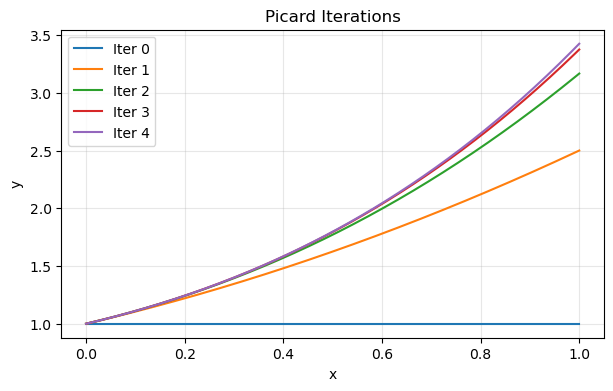

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def picard_method_x_plus_y(y0=1.0, iterations=4):
    coeffs = [y0]
    coeffs_list = [coeffs[:]]

    for _ in range(iterations):
        integrand = coeffs[:]
        if len(integrand) < 2:
            integrand += [0.0] * (2 - len(integrand))
        integrand[1] += 1.0

        next_coeffs = [0.0] * (len(integrand) + 1)
        next_coeffs[0] = y0
        for i, c in enumerate(integrand):
            next_coeffs[i + 1] = c / (i + 1)

        coeffs = next_coeffs
        coeffs_list.append(coeffs[:])

    return coeffs, coeffs_list


def eval_polynomial(coeffs, x):
    return sum(c * (x ** i) for i, c in enumerate(coeffs))


coeffs, coeffs_list = picard_method_x_plus_y(y0=1.0, iterations=4)
approx = eval_polynomial(coeffs, 1.0)
print("Approximate y(1):", approx)

rows = []
for i, c in enumerate(coeffs_list):
    rows.append({"iter": i, "coeffs": c, "y(1)": eval_polynomial(c, 1.0)})
table = pd.DataFrame(rows)
display(table)

xs = np.linspace(0.0, 1.0, 200)
plt.figure(figsize=(7, 4))
for i, c in enumerate(coeffs_list):
    ys = [eval_polynomial(c, x) for x in xs]
    label = f"Iter {i}"
    plt.plot(xs, ys, label=label)
plt.title("Picard Iterations")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Time Complexity: O(k^2)

Space Complexity: O(k)

### Method 7.4: Taylor Series Method

**Assumptions**

- f(x, y) is differentiable as needed.
- Initial condition y(x0) = y0 is given.
- Order p is chosen.

**Algorithm (Taylor Series Method)**

1. Start
2. Read f(x, y), x0, y0, order p
3. Compute series coefficients up to order p
4. Evaluate polynomial at x
5. Print value
6. Stop
7. End

Approximate y(1): 3.436111111111111


,n,coeff
0,0,1.000000
1,1,1.000000
2,2,1.000000
3,3,0.333333
4,4,0.083333
5,5,0.016667
6,6,0.002778


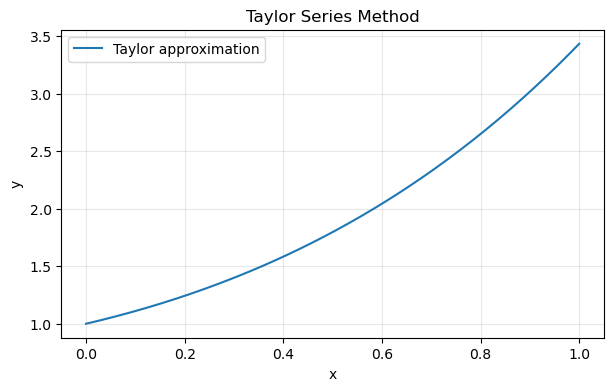

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def taylor_series_method_x_plus_y(y0, x, order):
    coeffs = [0.0] * (order + 1)
    coeffs[0] = y0

    for n in range(order):
        rhs = coeffs[n] + (1.0 if n == 1 else 0.0)
        coeffs[n + 1] = rhs / (n + 1)

    value = sum(coeffs[n] * (x ** n) for n in range(order + 1))
    return value, coeffs


approx, coeffs = taylor_series_method_x_plus_y(1.0, 1.0, 6)
print("Approximate y(1):", approx)

rows = [{"n": i, "coeff": c} for i, c in enumerate(coeffs)]
table = pd.DataFrame(rows)
display(table)

xs = np.linspace(0.0, 1.0, 200)
ys = [sum(coeffs[n] * (x ** n) for n in range(len(coeffs))) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="Taylor approximation")
plt.title("Taylor Series Method")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Time Complexity: O(p)

Space Complexity: O(p)